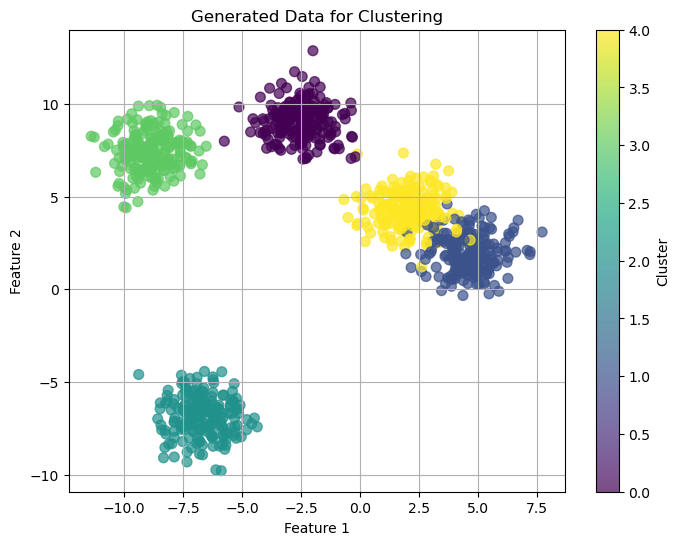

In [93]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import mode
import numpy as np
import pandas as pd
from tqdm import tqdm
%matplotlib inline
np.random.seed(101)

# Generate synthetic data
X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title('Generated Data for Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


In [75]:
class StrongCoresets:
    def __init__(self, num_clusters, num_coresets, X, max_iters=100, tol=1e-4):
        self.num_clusters = num_clusters
        self.num_coresets = num_coresets
        self.max_iters = max_iters
        self.tol = tol
        self.X = X
        self.centroids = None
        self.labels = None
        self.coresets = None
        self.clusters = None
        self.distances = np.zeros(X.shape[0])
        self.alpha = 16*(np.log(num_clusters) + 2)
        self.covariance = np.cov(X, rowvar=False)

    @staticmethod
    def mahalanobis_distance(x, mean, covariance):
        diff = x - mean
        inv_covariance = np.linalg.inv(covariance)
        md = np.sqrt(np.dot(np.dot(diff.T, inv_covariance), diff))
        return md
    
    def initialize_centers(self):
        centers = [np.random.randint(self.X.shape[0])]
        distances = np.zeros(self.X.shape[0])
        for _ in range(1, self.num_clusters):
            for i, x in enumerate(self.X):
                distances[i] = min([self.mahalanobis_distance(x, self.X[center], self.covariance) for center in centers])
            probabilities = distances**2  / np.sum(distances**2)
            next_center_index = np.random.choice(np.arange(X.shape[0]), p=probabilities)
            centers.append(next_center_index)
        self.centroids = np.array(centers)
        return self.centroids
    
    def assign_points_to_clusters(self):
        clusters = [[] for _ in range(len(self.centroids))]
        covariance = np.cov(self.X, rowvar=False)
        for i, x in enumerate(self.X):
            distances = [self.mahalanobis_distance(x, self.X[center], self.covariance) for center in self.centroids]
            closest_center_index = np.argmin(distances)
            self.distances[i] = distances[closest_center_index]
            clusters[closest_center_index].append(i)
        self.clusters = clusters
        return clusters
    
    def run(self):
        self.initialize_centers()
        clusters = self.assign_points_to_clusters()
        c = np.mean(self.distances)
        s = np.zeros(X.shape[0])
        for i, center in enumerate(self.centroids):
            distances = self.distances[clusters[i]]
            s[clusters[i]] = distances*self.alpha/c
            s[clusters[i]] += 2*sum(distances)/(len(distances)*c) + 4*(len(self.X))/len(distances)
        probabilities = s / np.sum(s)
        indices = np.arange(len(probabilities))
        sampled_indices = np.random.choice(indices, size=self.num_coresets, p=probabilities)
        self.coresets = X[sampled_indices]
        self.weights = 1/(self.num_coresets*probabilities[sampled_indices])
        return self.coresets, self.weights
    
    def kmeans(self):
        data = np.asarray(self.coresets)
        mins = data.min(axis=0)
        maxs = data.max(axis=0)
        centroids = np.random.rand(self.num_clusters, data.shape[1]) * (maxs - mins) + mins
        
        for _ in range(self.max_iters):
            dist = cdist(data, centroids)
            weighted_dist = dist * self.weights[:, np.newaxis]
            labels = np.argmin(weighted_dist, axis=1)
            
            for j in range(self.num_clusters):
                cluster = labels == j
                if self.weights[cluster].sum() > 0:
                    centroids[j] = np.average(data[cluster], axis=0, weights=self.weights[cluster])
                else:
                    centroids[j] = np.random.rand(1, data.shape[1]) * (maxs - mins) + mins
        
        return centroids
    
    def predict(self, X, centroids):
        distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(distances, axis=0)
        return labels

In [78]:
strongCoresests = StrongCoresets(num_clusters=5, num_coresets=50, X=X)
coresets, weights = strongCoresests.run()
centroids = strongCoresests.kmeans()
preds = strongCoresests.predict(X, centroids)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


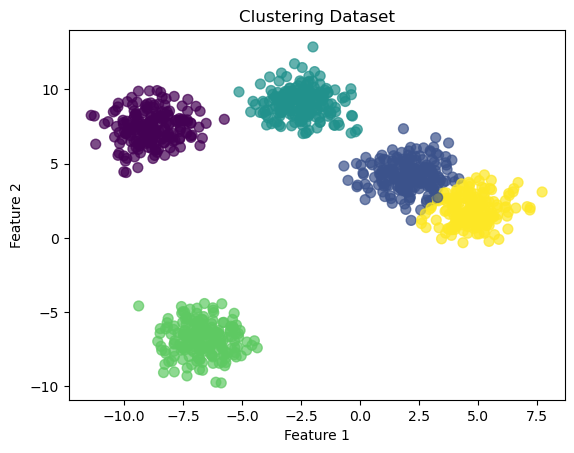

In [79]:
plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clustering Dataset')
plt.show()

In [85]:
def kmeans(data, num_clusters, max_iters=100):
    data = np.asarray(data)
    mins = data.min(axis=0)
    maxs = data.max(axis=0)
    centroids = np.random.rand(num_clusters, data.shape[1]) * (maxs - mins) + mins
    
    for _ in range(max_iters):
        dist = cdist(data, centroids)
        weighted_dist = dist
        labels = np.argmin(weighted_dist, axis=1)
        
        for j in range(num_clusters):
            cluster = labels == j
            centroids[j] = np.average(data[cluster], axis=0)
    
    return centroids

In [86]:
centers = kmeans(X, 5)

/Users/shubhagarwal/anaconda3/envs/nlp/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/shubhagarwal/anaconda3/envs/nlp/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [89]:
def predict(X, centroids):
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    labels = np.argmin(distances, axis=0)
    return labels

In [91]:
preds = predict(X, centers)

In [92]:
preds.shape

(10000,)

In [97]:
from time import time

start_time = time()
strong_coresets = StrongCoresets(num_clusters=5, num_coresets=50, X=X)
coresets, weights = strong_coresets.run()
centroids = strong_coresets.kmeans()
end_time = time()
strong_coresets_time = end_time - start_time
print(f'Strong Coreset Time: {strong_coresets_time:.4f}')
print(f'Rand Index: {rand_score(y, strong_coresets.predict(X, centroids)):.4f}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Strong Coreset Time: 0.2292
Rand Index: 0.9042


In [98]:
start_time = time()
centers = kmeans(X, 5)
preds = predict(X, centers)
end_time = time()
kmeans_time = end_time - start_time
print(f'KMeans Time: {kmeans_time:.4f}')
print(f'Rand Index: {rand_score(y, preds):.4f}')

KMeans Time: 0.0334
Rand Index: 0.9847
